In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn. linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "https://gist.githubusercontent.com/msporyshev/537e1f812142eb7f547d178f43222b5e/raw/77d3a17399b7fc3a7651151c46605c0024729241/advertising.csv"
df = pd. read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

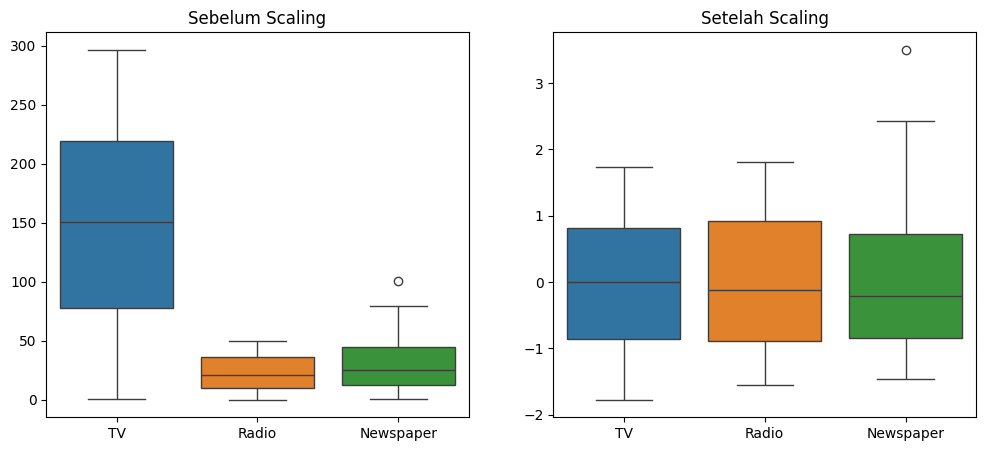

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler. fit_transform(X_train)
X_test_scaled = scaler. transform(X_test)

fig, ax = plt.subplots(1,2, figsize=(12,5))
sns. boxplot(data=X_train [ ['TV', 'Radio', 'Newspaper' ]], ax=ax [0])
ax [0]. set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train. columns)

sns.boxplot (data=X_train_scaled_df[['TV', 'Radio', 'Newspaper' ]], ax=ax [1] )
ax [1] . set_title("Setelah Scaling")
plt.show()

In [7]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict (X_train_scaled)
y_pred_test_lr = lr.predict (X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np. sqrt(mean_squared_error(y_test, y_pred_test_lr))
print ("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr. coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349232
Coefficients: [4.58720774 1.48984025 0.08791597]


In [8]:
ridge = Ridge(alpha=1.0)
ridge. fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np. sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge. coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919387
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [9]:
lasso = Lasso(alpha=0.1)
lasso. fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)

y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso. coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


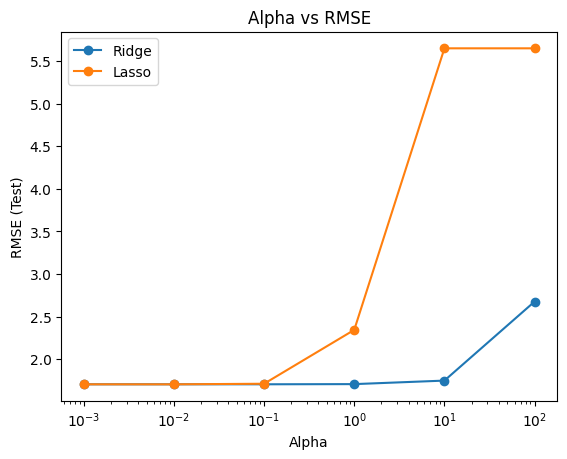

In [11]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)
    
    ridge_rmse. append (np. sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse. append (np. sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))
    
plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt. legend()
plt. title("Alpha vs RMSE")
plt.show()

In [12]:
alphas_extra = [0.005, 0.02, 0.2, 2, 50]
ridge_rmse_extra = []
lasso_rmse_extra = []

for a in alphas_extra:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    ridge_rmse_extra.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse_extra.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

print("Ridge RMSE (extra alphas):", dict(zip(alphas_extra, ridge_rmse_extra)))
print("Lasso RMSE (extra alphas):", dict(zip(alphas_extra, lasso_rmse_extra)))

Ridge RMSE (extra alphas): {0.005: np.float64(1.7052243393359814), 0.02: np.float64(1.7052535717615134), 0.2: np.float64(1.7056140712548453), 2: np.float64(1.7101782898769866), 50: np.float64(2.1490221569764474)}
Lasso RMSE (extra alphas): {0.005: np.float64(1.7050968174353074), 0.02: np.float64(1.7050353891312648), 0.2: np.float64(1.7431899263913697), 2: np.float64(3.2910606923931702), 50: np.float64(5.648216567255986)}


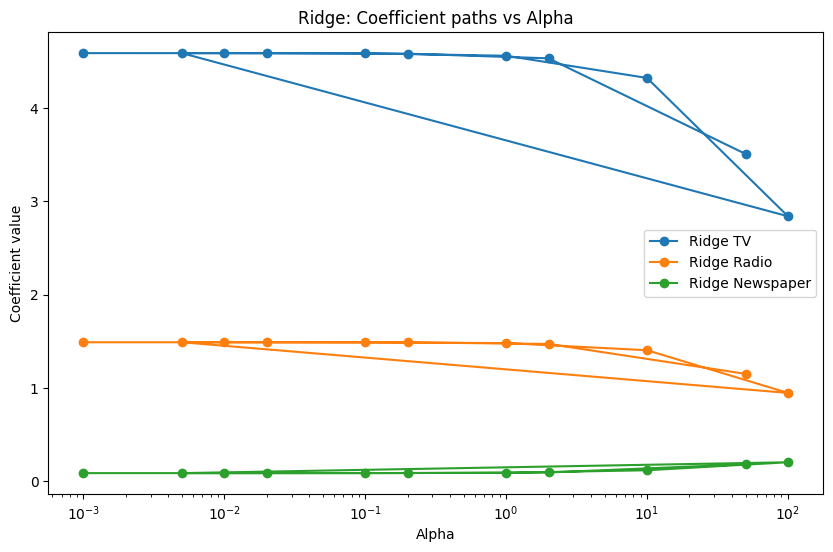

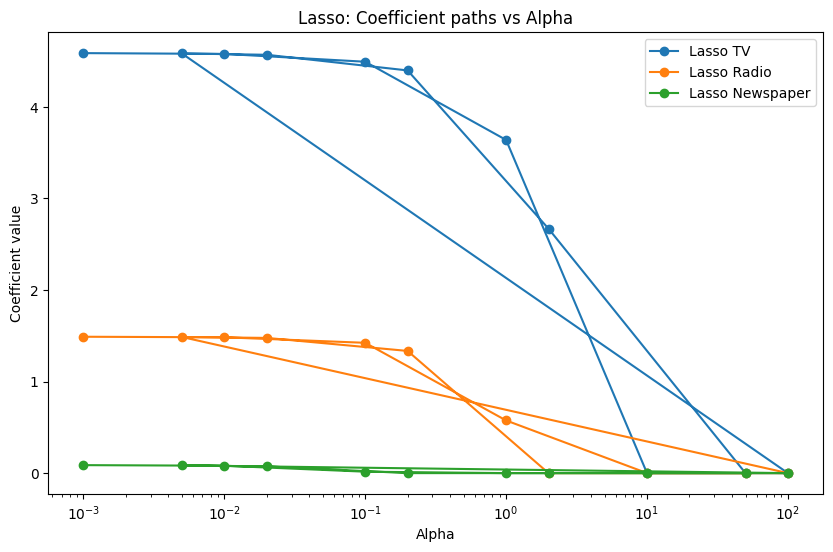

In [13]:
plt.figure(figsize=(10,6))
for i, feat in enumerate(X.columns):
    coefs = []
    for a in alphas + alphas_extra:
        r = Ridge(alpha=a).fit(X_train_scaled, y_train)
        coefs.append(r.coef_[i])
    plt.plot(alphas + alphas_extra, coefs, marker='o', label=f'Ridge {feat}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient value')
plt.title('Ridge: Coefficient paths vs Alpha')
plt.legend()
plt.show()

# Lasso coefficients path
plt.figure(figsize=(10,6))
for i, feat in enumerate(X.columns):
    coefs = []
    for a in alphas + alphas_extra:
        l = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
        coefs.append(l.coef_[i])
    plt.plot(alphas + alphas_extra, coefs, marker='o', label=f'Lasso {feat}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient value')
plt.title('Lasso: Coefficient paths vs Alpha')
plt.legend()
plt.show()